# Jaguar Re-ID — ViT Naïf v2

**Architecture** : Vision Transformer naïf (cours) — **embed_dim=64** (vs 8 en v1)  
**Changement principal** : augmentation massive de la capacité du modèle pour combattre l'underfitting sévère (9.5 % en v1)

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776182956.843248   65424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776182956.874226   65424 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776182957.636212   65424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776182958.290900   65424 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
MODEL_NAME   = 'vit_naive_v2'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

# ViT architecture hyperparameters
EMBED_DIM  = 64      # Patch embedding dimension (8 → 64 : ×8 vs v1)
NUM_BLOCKS = 3       # Number of transformer blocks (identique à v1)
PATCH_SIZE = 16      # Patch size (16x16 pixels)

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1776182961.317491   65424 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776182961.409256   65424 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12615 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

Même architecture ViT naïf que v1, mais avec **embed_dim=64** au lieu de 8.

| Paramètre | v1 | v2 | Effet |
|-----------|----|----|-------|
| embed_dim | 8 | **64** | ×8 features par patch |
| real_dim (196 + embed_dim) | 204 | **260** | +27 % dimension effective |
| Ratio info utile | 8/204 = 4 % | **64/260 = 25 %** | ×6 signal vs bruit positionnel |
| Params estimés | ~80K | ~1M+ | Plus de capacité d'apprentissage |

In [4]:
def positional_embedding(embedded_patches):
    """One-hot positional encoding (cours) : concat one-hot(position) to each patch."""
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def build_model():
    input_tensor = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = input_tensor

    # Patch embedding : Conv2D splits image into patches
    x = layers.Conv2D(EMBED_DIM, (PATCH_SIZE, PATCH_SIZE), strides=(PATCH_SIZE, PATCH_SIZE),
                      activation='linear', use_bias=False, padding='valid')(x)
    sequence_length = x.shape[1] * x.shape[2]  # 14*14 = 196
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = layers.Reshape((sequence_length, EMBED_DIM))(x)

    # Positional encoding : one-hot concat
    x = layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + EMBED_DIM  # 196 + 64 = 260

    # Transformer blocks
    for _ in range(NUM_BLOCKS):
        # Self-attention
        old_x = x
        x = layers.LayerNormalization()(x)

        Q = layers.Dense(real_embedding_dim, activation='tanh')(x)
        K = layers.Dense(real_embedding_dim, activation='tanh')(x)
        V = layers.Dense(real_embedding_dim, activation='tanh')(x)

        Kt = layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = layers.Softmax()(QKt)
        x = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = layers.Add()([x, old_x])

        # Feed-forward
        old_x = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(real_embedding_dim, activation='tanh')(x)
        x = layers.Dense(real_embedding_dim, activation='tanh')(x)
        x = layers.Add()([x, old_x])

    # Classification head
    x = layers.Flatten()(x)
    x = layers.Dense(real_embedding_dim, activation='tanh', name='embedding')(x)
    output_tensor = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(input_tensor, output_tensor, name=MODEL_NAME)
    return model


model = build_model()
model.summary()

Model: "vit_naive_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,152 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 260)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 260)  │        520 │ lambda[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 260, 196)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 196)  │          0 │ dense[0][0],      │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 196, 196)  │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 196, 260)  │          0 │ softmax[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 260)  │          0 │ lambda_3[0][0],   │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 260)  │     67,860 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 260)  │          0 │ dense_4[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,328,123 (54.66 MB)

 Trainable params: 14,328,123 (54.66 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (vit_naive_v2) ===


I0000 00:00:1776182967.464167   65522 service.cc:153] XLA service 0x7f8594046610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776182967.464251   65522 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776182967.551622   65522 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776182968.115991   65522 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776182968.149609   65522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10106__.100
I0000 00:00:1776182968.564653   65666 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776182968.751084   65663 subprocess_compilation.cc:348] ptxas warn

  lr_0.01: val_acc=0.0950 (best epoch=77)


I0000 00:00:1776183049.679893   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87572__.100
I0000 00:00:1776183053.738746   65522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87572__.100
I0000 00:00:1776183057.151370   65519 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88914__.28
I0000 00:00:1776183055.869006   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88914__.28


  lr_0.001: val_acc=0.0950 (best epoch=57)


I0000 00:00:1776183092.178801   65520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_149090__.100
I0000 00:00:1776183096.317211   65519 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_149090__.100
I0000 00:00:1776183099.896947   65519 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_150432__.28
I0000 00:00:1776183101.131899   65520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_150432__.28


  lr_0.0005: val_acc=0.0950 (best epoch=55)


I0000 00:00:1776183137.889325   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_209509__.100
I0000 00:00:1776183142.072013   65522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_209509__.100
I0000 00:00:1776183145.591700   65519 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_210851__.28
I0000 00:00:1776183144.373239   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_210851__.28


  lr_0.0001: val_acc=0.0950 (best epoch=11)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.01,0.094987,77
1,lr_0.001,0.094987,57
2,lr_0.0005,0.094987,55
3,lr_0.0001,0.094987,11



Best: lr_0.01 → val_acc=0.0950


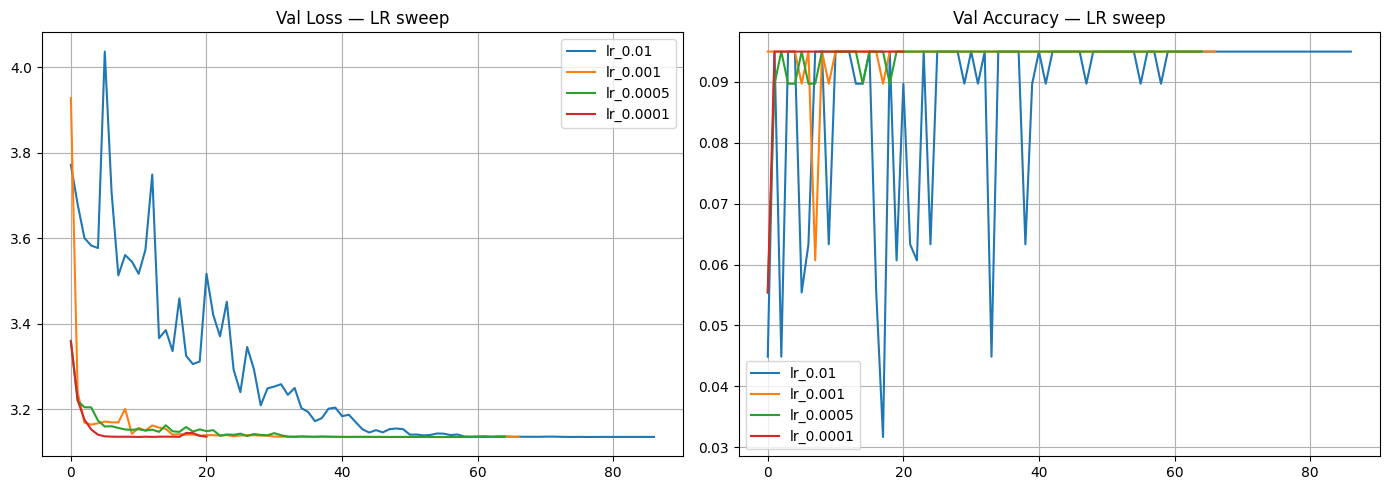

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776183159.609180   65518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_236495__.100


47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0473 - loss: 4.5134

I0000 00:00:1776183163.952895   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_236495__.100


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0476 - loss: 4.5037

I0000 00:00:1776183167.679535   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237837__.28
I0000 00:00:1776183168.960519   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237837__.28


48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.0607 - loss: 4.0466 - val_accuracy: 0.0950 - val_loss: 3.5459 - learning_rate: 0.0100
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0653 - loss: 3.5766 - val_accuracy: 0.0185 - val_loss: 3.4608 - learning_rate: 0.0100
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0633 - loss: 3.6092 - val_accuracy: 0.0449 - val_loss: 3.6219 - learning_rate: 0.0100
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0706 - loss: 3.6189 - val_accuracy: 0.0950 - val_loss: 3.4230 - learning_rate: 0.0100
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0752 - loss: 3.5950 - val_accuracy: 0.0897 - val_loss: 3.6077 - learning_rate: 0.0100
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ -2s -32609us/step - accuracy: 0.0818 - loss: 3.6221 - val_accuracy: 0.0449 - val_loss: 3.5622 - learning_rate: 0.0100
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0666 - loss: 3.5627 - val_a

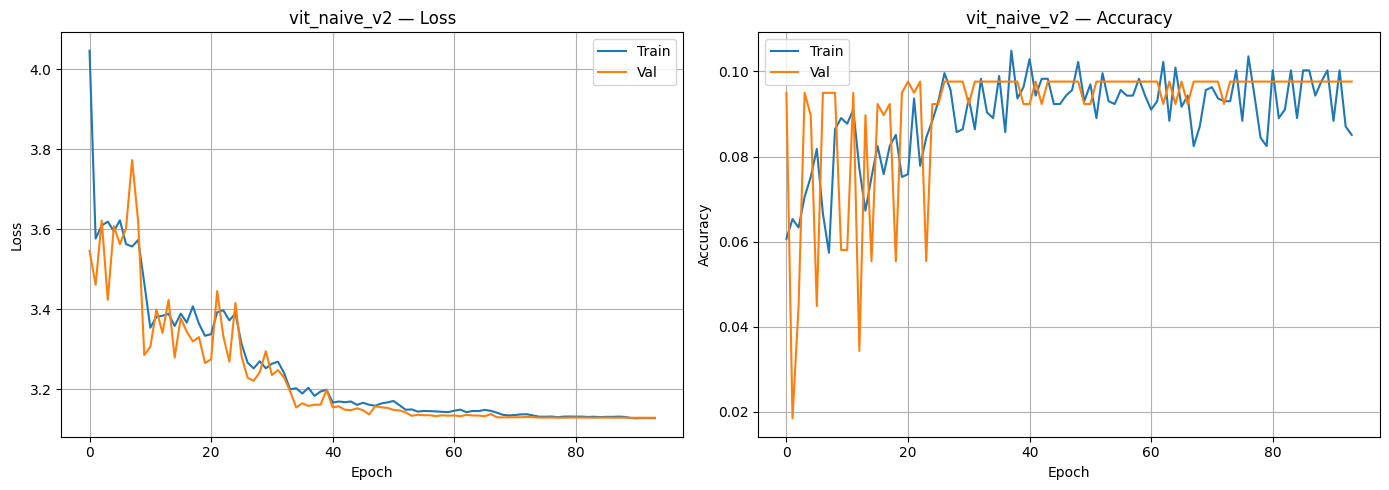

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

I0000 00:00:1776183257.934633   65522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237837__.28


vit_naive_v2 (best LR=0.01):
  Train — Loss: 3.1248, Acc: 0.1003
  Val   — Loss: 3.1281, Acc: 0.0976


I0000 00:00:1776183259.361279   65522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_910422__.21
I0000 00:00:1776183260.590995   65518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_910913__.21


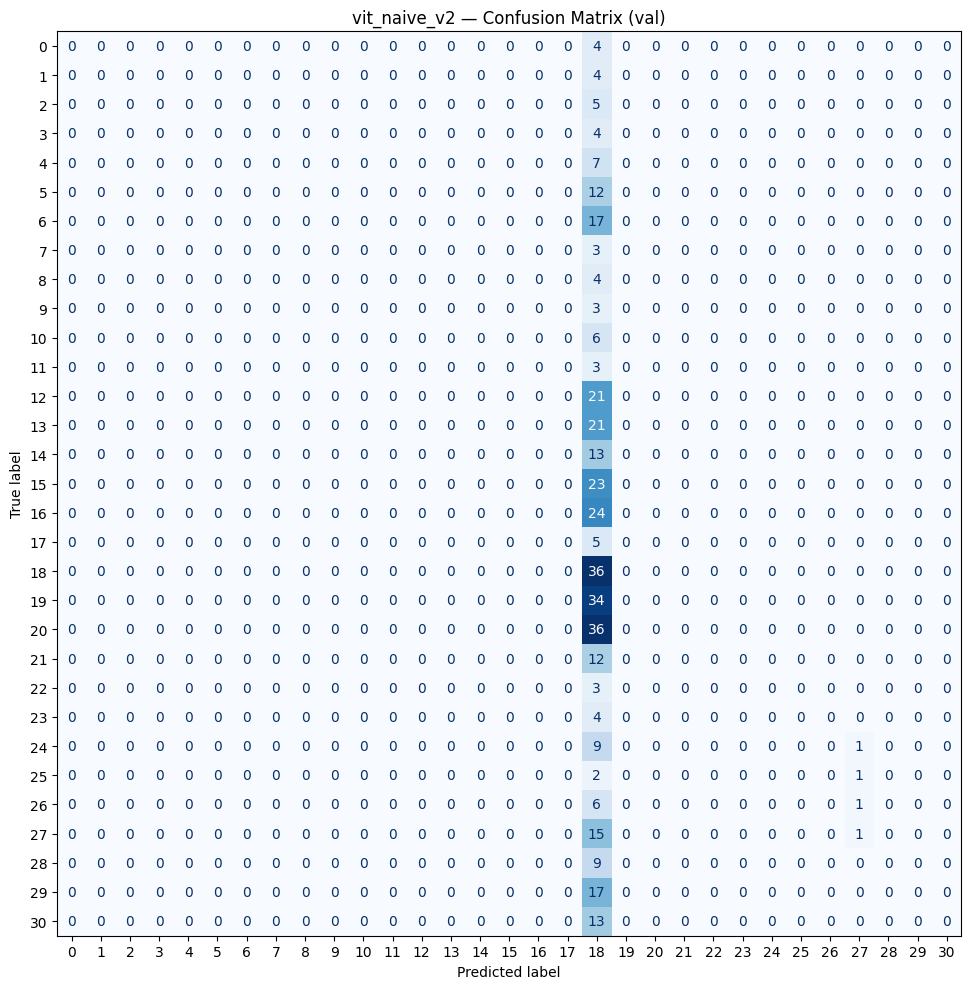

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 77 epochs
Epoch 1/77


I0000 00:00:1776183265.052954   65522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_920636__.100


56/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0672 - loss: 4.1345

I0000 00:00:1776183269.486170   65518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_920636__.100
I0000 00:00:1776183269.813696   91524 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776183269.902633   91527 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776183269.945770   91536 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1776183270.221754   91533 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776183270.395276   91531 subprocess_com

60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.0744 - loss: 3.8177
Epoch 2/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0813 - loss: 3.5124
Epoch 3/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0797 - loss: 3.6595
Epoch 4/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0776 - loss: 3.6444
Epoch 5/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0765 - loss: 3.6374
Epoch 6/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0697 - loss: 3.5941
Epoch 7/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0723 - loss: 3.6812
Epoch 8/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0744 - loss: 3.6516
Epoch 9/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0744 - loss: 3.6519
Epoch 10/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0855 - loss: 3.6258
Epoch 11/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0739 - loss: 3.6741
Epoch 12/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0665 - loss: 3.6

I0000 00:00:1776183322.979225   65518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_980444__.28
I0000 00:00:1776183324.384509   65519 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_980444__.28


Final train acc: 0.0897


In [14]:
# Extract embeddings from the layer before softmax
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('embedding').output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

I0000 00:00:1776183323.168815   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_981190__.19


 1/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step

I0000 00:00:1776183324.315219   65521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_981657__.19
I0000 00:00:1776183324.562628   94986 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776183324.710274   94995 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776183325.011780   94993 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776183325.069332   94989 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776183325.126203   94986 subprocess_compilation.cc:348

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 424ms/step
Embedding shape: (371, 260)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_vit_naive_v2.csv


,row_id,similarity
0,0,1.0
1,1,1.0
2,2,1.0
3,3,1.0
4,4,1.0


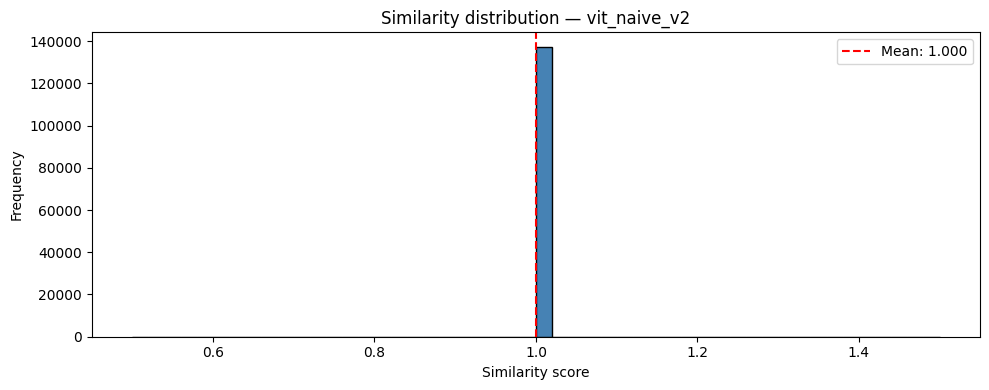

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Results

| Metrique | Train | Val |
|----------|-------|-----|
| Accuracy | TODO  | TODO |
| Loss     | TODO  | TODO |
| Overfitting ? | — | TODO |
| Kaggle Score (public) | — | TODO |
| Kaggle Score (private) | — | TODO |

### Analysis

- TODO : Impact de embed_dim=64 vs 8 (capacité)
- TODO : LR sweep results — quel LR est optimal avec plus de capacité ?
- TODO : Underfitting/overfitting ? Le modèle apprend-il maintenant ?
- TODO : Qualité des embeddings (distribution des similarités vs v1)

### Verdict

- [ ] Improvable -> Instructions for vN+1
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff this architecture, why ?

### Interpretation

_Free Space : On note ce qu'on a a dire sur ce notebook, servira pour la soutenance._